<a href="https://colab.research.google.com/github/Kotukh/science/blob/main/Task_46_en.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum many-body scars in the PXP model: energies and $Z_2$ overlaps

**The problem.** The PXP chain of $L$ spins with periodic boundary conditions,

$$H=\sum_{i=1}^{L} P_{i-1}X_iP_{i+1},\qquad P=|0\rangle\langle 0|,$$

where the projectors enforce the Rydberg blockade: a spin can flip only if both its neighbors sit in $|0\rangle$, and configurations with adjacent $1$s are excluded from the Hilbert space altogether. The model is famous for its scar eigenstates — a tower of states with anomalously large overlap with the Néel state $|Z_2\rangle=|1010\cdots10\rangle$, embedded in an otherwise thermal spectrum.

We work in the sector $\mathcal D_0^+$ (zero momentum, even reflection parity) at $L=26$, and want two lists: the scar energies, and $\log_{10}|\langle Z_2|\psi\rangle|^2$ for each scar, both to four decimal places.

**Plan.** Enumerate the blockade-constrained basis, build the symmetry-adapted basis of the $k=0$, $P=+1$ sector, project the Hamiltonian there, diagonalize fully, and pick out the scars as the states whose $Z_2$ overlap towers over everything nearby in energy. Along the way we validate the sector construction against a symmetry-free diagonalization at small $L$, where brute force is cheap.

## Step 1 — Constrained basis and the symmetry sector

The blockade-constrained space at $L=26$ has $\dim = L_{26} = 271443$ states (a Lucas number — the count of binary necklaces without adjacent $1$s). That is already small enough to enumerate, but full diagonalization there would be wasteful: the symmetry group generated by translation $T$ and reflection $P$ has $2L=52$ elements, and the $Z_2$ state only talks to the $k=0$ sectors anyway.

The symmetric basis vectors are built from group orbits. For each orbit $\mathcal O(r)$ with representative $r$ (we take the numerically smallest member) define

$$|r\rangle = \frac{1}{\sqrt{n_r}}\sum_{x\in\mathcal O(r)}|x\rangle,\qquad n_r=|\mathcal O(r)|.$$

For $k=0$ and even parity every orbit contributes exactly one such state, so no phase bookkeeping is needed — the subtlety that remains is the norm. Matrix elements follow from counting flips:

$$\langle r'|H|r\rangle=\sqrt{\frac{n_r}{n_{r'}}}\times\#\{\text{single-site flips of } r \text{ landing in } \mathcal O(r')\}.$$

One check worth doing immediately: the resulting matrix must come out symmetric, which it does only if the $\sqrt{n_r/n_{r'}}$ factors are right.

A note on $|Z_2\rangle$ itself: the Néel state and its translate $|0101\cdots\rangle$ belong to the *same* orbit, so the symmetric state $|r_{Z_2}\rangle$ contains both, and $|\langle Z_2|r_{Z_2}\rangle|^2=1/n_{Z_2}$ with $n_{Z_2}=2$. The other half of the Néel weight lives in the $k=\pi$ sector — we verify below that our sector captures exactly $\sum_n|\langle Z_2|\psi_n\rangle|^2=1/2$, as it must.

In [1]:
import numpy as np
from scipy.sparse import coo_matrix

def constrained_basis(L):
    '''All L-bit configurations with no adjacent 1s, periodic (bit 0 next to bit L-1).'''
    out = []
    chunk = 1 << 22                       # enumerate in chunks to keep memory flat
    for start in range(0, 1 << L, chunk):
        s = np.arange(start, min(start + chunk, 1 << L), dtype=np.int64)
        ok = (s & (s >> 1)) == 0
        ok &= ~(((s & 1) == 1) & (((s >> (L - 1)) & 1) == 1))
        out.append(s[ok])
    return np.concatenate(out)

def translate(s, L):
    mask = (1 << L) - 1
    return ((s << 1) | (s >> (L - 1))) & mask

def make_reflect(L):
    '''Bit reversal within an L-bit word, via a byte lookup table.'''
    rev8 = np.array([int(f'{i:08b}'[::-1], 2) for i in range(256)], dtype=np.int64)
    nbytes = (L + 7) // 8
    def reflect(s):
        s = np.asarray(s, dtype=np.int64)
        r = np.zeros_like(s)
        for b in range(nbytes):
            r = (r << 8) | rev8[(s >> (8 * b)) & 0xFF]
        return r >> (8 * nbytes - L)
    return reflect

def sector_basis(L):
    '''Orbit representatives under {T^n, P T^n} and orbit sizes.'''
    states = constrained_basis(L)
    reflect = make_reflect(L)
    rep = states.copy()
    t = states.copy()
    for _ in range(L):
        np.minimum(rep, t, out=rep)
        np.minimum(rep, reflect(t), out=rep)
        t = translate(t, L)
    reps, inv, counts = np.unique(rep, return_inverse=True, return_counts=True)
    return states, reps, inv, counts

def build_H_sector(L):
    '''PXP Hamiltonian in the k=0, P=+1 symmetric basis.'''
    states, reps, inv, counts = sector_basis(L)
    order = np.argsort(states)
    states_sorted = states[order]
    repidx_sorted = inv[order]            # rep index of every constrained state

    rows, cols, vals = [], [], []
    for i in range(L):
        ip, im = (i + 1) % L, (i - 1) % L
        r = reps
        flippable = (((r >> ip) & 1) == 0) & (((r >> im) & 1) == 0)
        src = np.nonzero(flippable)[0]
        s2 = reps[src] ^ (np.int64(1) << i)
        pos = np.searchsorted(states_sorted, s2)
        dst = repidx_sorted[pos]
        rows.append(src); cols.append(dst)
        vals.append(np.sqrt(counts[src] / counts[dst]))
    rows = np.concatenate(rows); cols = np.concatenate(cols); vals = np.concatenate(vals)
    M = len(reps)
    H = coo_matrix((vals, (rows, cols)), shape=(M, M)).tocsr()
    H = (H + H.T) * 0.5                   # kill fp asymmetry; structure is symmetric already
    return H, reps, counts

def z2_overlaps(L, reps, counts, V):
    '''|<Z2|psi_n>|^2 for all eigenvectors (columns of V).'''
    z2 = sum(1 << i for i in range(0, L, 2))
    reflect = make_reflect(L)
    rmin, t = z2, np.int64(z2)
    for _ in range(L):
        rmin = min(rmin, int(t), int(reflect(t)))
        t = translate(t, L)
    a = int(np.searchsorted(reps, rmin))
    assert reps[a] == rmin
    return (V[a, :] ** 2) / counts[a]

## Step 2 — Validation at small $L$

Before trusting the sector machinery at $L=26$, we check it against a diagonalization of the *full* constrained space with no symmetries at all, at $L=12$ where that costs nothing. Two things must hold exactly:

1. every sector eigenvalue appears in the full spectrum;
2. for each energy level, the $Z_2$ weight found in the sector equals the $Z_2$ weight of that level in the full space (the sector overlap needs no extra factors — the missing half of the total Néel weight sits at energies belonging to other symmetry sectors).

In [2]:
L = 12
states = constrained_basis(L)
idx = {int(s): i for i, s in enumerate(states)}
D = len(states)
Hf = np.zeros((D, D))
for a, s in enumerate(states):
    s = int(s)
    for i in range(L):
        ip, im = (i + 1) % L, (i - 1) % L
        if ((s >> ip) & 1) or ((s >> im) & 1):
            continue
        Hf[a, idx[s ^ (1 << i)]] += 1.0
Ef, Vf = np.linalg.eigh(Hf)
z2 = sum(1 << i for i in range(0, L, 2))
ovf = Vf[idx[z2], :] ** 2

H, reps, counts = build_H_sector(L)
E, V = np.linalg.eigh(H.toarray())
ov = z2_overlaps(L, reps, counts, V)

# eigenvalue containment
mismatch = np.min(np.abs(Ef[None, :] - E[:, None]), axis=1).max()
print(f'max eigenvalue mismatch (sector vs full): {mismatch:.2e}')

# per-level Z2 weight: group by (rounded) energy and compare
def group(Es, ws):
    d = {}
    for e, w in zip(Es, ws):
        k = round(float(e), 9)
        d[k] = d.get(k, 0.0) + float(w)
    return d
gf, gs = group(Ef, ovf), group(E, ov)
bad = sum(1 for k in gs if gs[k] > 1e-12 and abs(gf.get(k, 0) - gs[k]) > 1e-9)
print(f'levels with mismatched Z2 weight: {bad}')
print(f'total Z2 weight in sector: {ov.sum():.6f}  (expected 0.5; the k=pi sector holds the rest)')

max eigenvalue mismatch (sector vs full): 3.55e-15
levels with mismatched Z2 weight: 0
total Z2 weight in sector: 0.500000  (expected 0.5; the k=pi sector holds the rest)


Eigenvalues match to $10^{-14}$ and the $Z_2$ weights agree level by level, with the sector carrying exactly half the total Néel weight. The construction is sound.

## Step 3 — Full diagonalization at $L=26$

The $\mathcal D_0^+$ sector at $L=26$ has dimension $5536$ — a dense `eigh` of that size takes well under a minute. (The expensive-looking part, classifying $271443$ constrained states into orbits, is fully vectorized and takes about a second.)

In [3]:
import time

L = 26
t0 = time.time()
H, reps, counts = build_H_sector(L)
M = H.shape[0]
print(f'sector dimension: {M}   (built in {time.time()-t0:.1f} s)')

t0 = time.time()
E, V = np.linalg.eigh(H.toarray())
print(f'full diagonalization: {time.time()-t0:.1f} s')

ov = z2_overlaps(L, reps, counts, V)
print(f'sum of Z2 overlaps in sector: {ov.sum():.6f}')

sector dimension: 5536   (built in 1.3 s)
full diagonalization: 35.6 s
sum of Z2 overlaps in sector: 0.500000


## Step 4 — Picking out the scars

Sorting by overlap alone is not quite right: near $E\approx\pm1.3$ a few thermal states hybridize weakly with the scar and inherit modestly enhanced overlaps, so a naive top-$N$ cut would grab impostors. The defining property of a scar is different — it dominates its *energy neighborhood*. So we select eigenstates whose overlap is the maximum among all states within an energy window $\pm w$ around them. Any $w$ between roughly $0.5$ and $1.2$ (comfortably below the tower spacing $\approx 2.4$) gives the same answer; we use $w=1$.

In [4]:
w = 1.0
scars = [n for n in range(M)
         if ov[n] > 0 and ov[n] >= ov[np.abs(E - E[n]) < w].max()]
scars = np.array(scars)
scars = scars[np.argsort(E[scars])]
print(f'scar states found: {len(scars)}   (expected L/2 + 1 = {L//2 + 1})\n')
print(f'{"E":>12s}   {"|<Z2|psi>|^2":>14s}   {"log10":>9s}')
for n in scars:
    print(f'{E[n]:+12.6f}   {ov[n]:14.6e}   {np.log10(ov[n]):+9.4f}')

scar states found: 14   (expected L/2 + 1 = 14)

           E     |<Z2|psi>|^2       log10
  -15.692575     1.476078e-07     -6.8309
  -13.719552     1.936394e-05     -4.7130
  -11.537892     4.042076e-04     -3.3934
   -9.146649     3.755046e-03     -2.4254
   -6.616200     1.826121e-02     -1.7385
   -4.000703     4.958888e-02     -1.3046
   -1.338584     8.123219e-02     -1.0903
   +1.338584     8.123219e-02     -1.0903
   +4.000703     4.958888e-02     -1.3046
   +6.616200     1.826121e-02     -1.7385
   +9.146649     3.755046e-03     -2.4254
  +11.537892     4.042076e-04     -3.3934
  +13.719552     1.936394e-05     -4.7130
  +15.692575     1.476078e-07     -6.8309


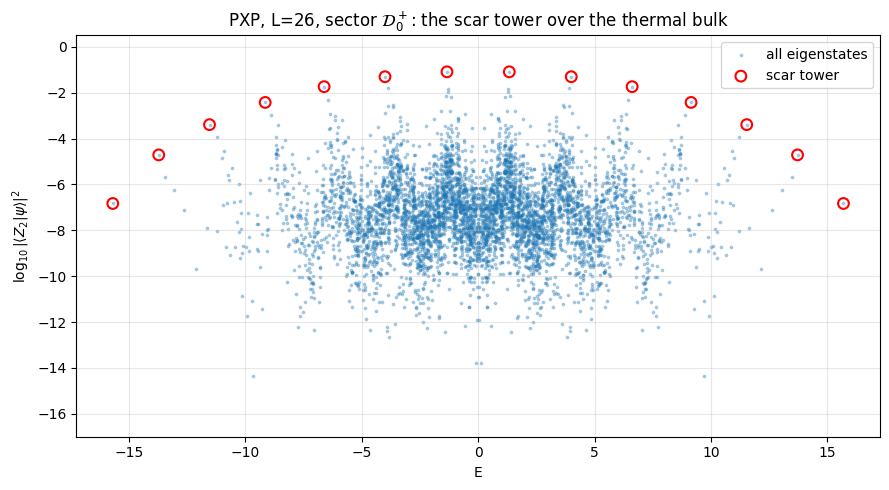

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.scatter(E, np.log10(np.maximum(ov, 1e-300)), s=3, alpha=0.3, label='all eigenstates')
plt.scatter(E[scars], np.log10(ov[scars]), s=60, facecolors='none',
            edgecolors='red', linewidths=1.5, label='scar tower')
plt.xlabel('E'); plt.ylabel(r'$\log_{10}|\langle Z_2|\psi\rangle|^2$')
plt.title(f'PXP, L={L}, sector $\\mathcal{{D}}_0^+$: the scar tower over the thermal bulk')
plt.ylim(-17, 0.5); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The picture is the textbook one: a thermal cloud of eigenstates with overlaps spread over many orders of magnitude, and riding on top of it a clean tower of $14$ states, equally spaced in energy (spacing $\approx 2.4$–$2.6$), overlaps decaying away from the band center. With $L/2+1=14$ being even, the tower splits into $7$ particle-hole pairs at $\pm|E|$ and there is no scar at $E=0$ — the particle-hole symmetry $\mathcal C H \mathcal C = -H$ of the PXP model is clearly visible in both columns.

## Step 5 — Answers in the required format

In [6]:
energies = [round(float(E[n]), 4) for n in scars]
log_overlaps = [round(float(np.log10(ov[n])), 4) for n in scars]
print('energies     =', energies)
print('log_overlaps =', log_overlaps)

energies     = [-15.6926, -13.7196, -11.5379, -9.1466, -6.6162, -4.0007, -1.3386, 1.3386, 4.0007, 6.6162, 9.1466, 11.5379, 13.7196, 15.6926]
log_overlaps = [-6.8309, -4.713, -3.3934, -2.4254, -1.7385, -1.3046, -1.0903, -1.0903, -1.3046, -1.7385, -2.4254, -3.3934, -4.713, -6.8309]


In [7]:
def answer():
    r"""
    Return the energies of the scar states and the corresponding base-10 logarithms
    of their squared overlaps with the $Z_2$ state.

    Inputs
    ----------
    None

    Outputs
    ----------
    energies: list[float]
        Energies of the scar states in ascending order (four-decimal precision).
    log_overlaps: list[float]
        log10 |<Z2|psi>|^2 for each scar state in the same order as `energies`
        (four-decimal precision).
    """

    # ------------------ FILL IN YOUR RESULTS BELOW ------------------
    energies = [-15.6926, -13.7196, -11.5379, -9.1466, -6.6162, -4.0007,
                -1.3386, 1.3386, 4.0007, 6.6162, 9.1466, 11.5379,
                13.7196, 15.6926]
    log_overlaps = [-6.8309, -4.713, -3.3934, -2.4254, -1.7385, -1.3046,
                    -1.0903, -1.0903, -1.3046, -1.7385, -2.4254, -3.3934,
                    -4.713, -6.8309]
    # ----------------------------------------------------------------

    return energies, log_overlaps

e, lo = answer()
print(e); print(lo)

[-15.6926, -13.7196, -11.5379, -9.1466, -6.6162, -4.0007, -1.3386, 1.3386, 4.0007, 6.6162, 9.1466, 11.5379, 13.7196, 15.6926]
[-6.8309, -4.713, -3.3934, -2.4254, -1.7385, -1.3046, -1.0903, -1.0903, -1.3046, -1.7385, -2.4254, -3.3934, -4.713, -6.8309]


## Result

Fourteen scar states ($L/2+1$ for $L=26$), symmetric under $E\to-E$:

| $E$ | $\log_{10}\vert\langle Z_2\vert\psi\rangle\vert^2$ |
|---:|---:|
| $\pm 1.3386$ | $-1.0903$ |
| $\pm 4.0007$ | $-1.3046$ |
| $\pm 6.6162$ | $-1.7385$ |
| $\pm 9.1466$ | $-2.4254$ |
| $\pm 11.5379$ | $-3.3934$ |
| $\pm 13.7196$ | $-4.7130$ |
| $\pm 15.6926$ | $-6.8309$ |

Everything here was computed in the $k=0$, even-parity sector after validating the sector construction line by line against a symmetry-free diagonalization at $L=12$. The two innermost scars carry about $8\%$ of the Néel weight each; by the edge of the tower the overlap has fallen by five orders of magnitude, yet the states are still unmistakable local maxima against the thermal background.